In [ ]:
# Import necessary packages
import glob
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr

from hy2dl.evaluation import calculate_metrics
from hy2dl.utils import get_distribution

color_palette = {"LSTM": "#4daf4a", "benchmark": "#377eb8", "MTS": "#ff7f00", "sMTS": "#984ea3"}

In [33]:
def calculate_median_ensemble(path_folders: list[Path]) -> xr.Dataset:
    """
    Reads in multiple zarr datasets from the provided folders, extracts the 'y_obs' and 'y_sim' variables,
    and compiles them into a single xarray Dataset. The function also calculates the median of the 'y_sim'
    variables across all seeds and adds it as a new variable to the final dataset.

    Parameters:
    -----------
    path_folders : list[Path]
        A list of Path objects pointing to the folders containing the zarr datasets.

    Returns:
    --------
    xr.Dataset
        A compiled xarray Dataset containing 'y_obs', individual 'y_sim_seed_#' variables, and the median 'y_sim'.
    """

    # Dictionary to hold our individual datasets
    datasets = {}

    for folder in path_folders:
        # Extract the seed number from the folder name
        seed_num = folder.split("_seed_")[-1].strip("/\\")
        # Open the dataset and store it
        datasets[seed_num] = xr.open_zarr(folder + "testing_results.zarr")

    # Initialize the final dataset and extract y_obs (same for all cases)
    final_ds = xr.Dataset({"y_obs": datasets[list(datasets.keys())[0]]["y_obs"]})

    y_sim_per_seed = []
    # Add individual y_sim_seed_# variables to the new dataset
    for seed_num, ds in datasets.items():
        final_ds[f"y_sim_seed_{seed_num}"] = ds["y_sim"]
        y_sim_per_seed.append(ds["y_sim"])

    # 4. Calculate the ensemble median
    y_sim_concat = xr.concat(y_sim_per_seed, dim="seed")
    final_ds["y_sim"] = y_sim_concat.median(dim="seed")

    return final_ds

#### Benchmark CAMELS_GB.


Lees, T., Buechel, M., Anderson, B., Slater, L., Reece, S., Coxon, G., & Dadson, S. J. (2021). Benchmarking data-driven rainfall–runoff models in Great Britain: A comparison of long short-term memory (LSTM)-based models with four lumped conceptual models. Hydrology and Earth System Sciences, 25(10), 5517–5534. https://doi.org/10.5194/hess-25-5517-2021

In [34]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Lees2021"

In [35]:
# Read the results generated by Lees et al. (2021)
path_reference = path_data + "/reference/metrics.nc"
lees_metrics = xr.open_dataset(path_reference)
df_NSE_less = lees_metrics.sel(model="LSTM")["nse"].to_pandas()
df_NSE_less = df_NSE_less.to_frame(name="Benchmark_Lees")
df_NSE_less.index = df_NSE_less.index.astype(str)
df_NSE_less.index.name = "gauge_id"

In [36]:
# Calculate ensemble median and metrics for our LSTM results
path_results = glob.glob(path_data + "/results/*/")
ds = calculate_median_ensemble(path_results)
ds_metrics = calculate_metrics(ds_results=ds)
CAMELS_GB_metrics = ds_metrics.sel(metric="nse", feature="discharge_spec").round(3).T.to_pandas().to_frame(name="LSTM")

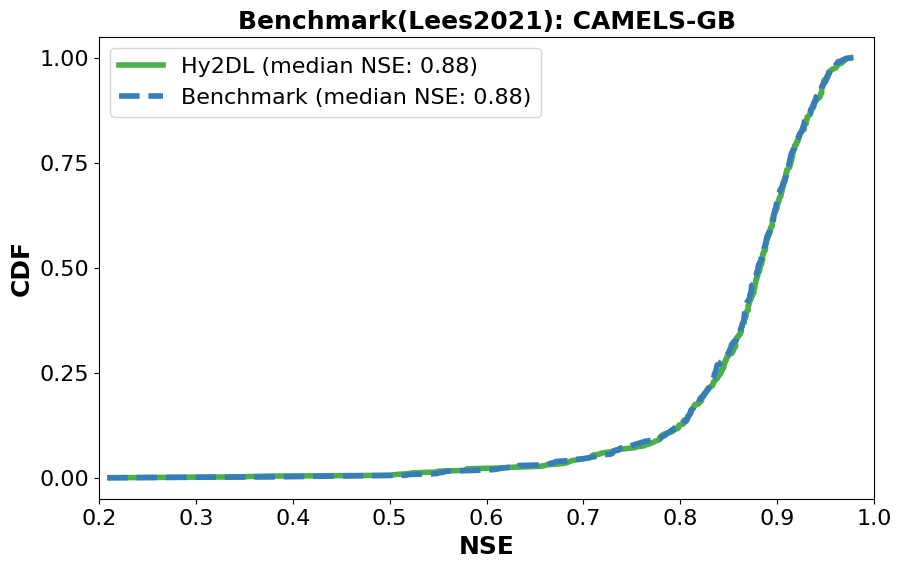

In [228]:
NSE_comparison = pd.concat([CAMELS_GB_metrics, df_NSE_less], axis=1)
NSE_comparison = NSE_comparison.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison["cdf"] = np.arange(len(NSE_comparison)) / (len(NSE_comparison) - 1)

# Create plot
plt.rcParams["figure.figsize"] = (10, 6)

plt.plot(
    NSE_comparison["LSTM"],
    NSE_comparison["cdf"],
    linewidth=4,
    label=f"Hy2DL (median NSE: {NSE_comparison['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
plt.plot(
    NSE_comparison["Benchmark_Lees"],
    NSE_comparison["cdf"],
    linewidth=4,
    linestyle="--",
    label=f"Benchmark (median NSE: {NSE_comparison['Benchmark_Lees'].median():.2f})",
    color=color_palette["benchmark"],
)


plt.xlim(0.2, 1)
plt.xlabel("NSE", fontsize=18, fontweight="bold")
plt.ylabel("CDF", fontsize=18, fontweight="bold")
plt.xticks(fontsize=16)
plt.yticks([i * 0.25 for i in range(5)], fontsize=16)

plt.legend(loc="upper left", fontsize=16)
plt.title("Benchmark(Lees2021): CAMELS-GB", fontsize=18, fontweight="bold")
# plt.savefig("Benchmark_Lees2021.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

#### Benchmark CAMELS_US

Kratzert, F., Klotz, D., Shalev, G., Klambauer, G., Hochreiter, S., & Nearing, G. (2019). Towards learning universal, regional, and local hydrological behaviors via machine learning applied to large-sample datasets. Hydrology and Earth System Sciences, 23(12), 5089–5110. https://doi.org/10.5194/hess-23-5089-2019

In [38]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Kratzert2019"

In [39]:
# Read the results generated by Kratzert et al. (2019)
path_reference = path_data + "/reference/all_metrics.p"
with open(path_reference, "rb") as f:
    kratzert_metrics = pickle.load(f)
df_NSE_Kratzert = pd.DataFrame(
    list(kratzert_metrics["NSE"]["lstm_NSE"]["ensemble"].items()), columns=["basin_id", "Benchmark_Kratzert"]
).set_index("basin_id")
df_NSE_Kratzert.index.name = "gauge_id"

In [96]:
# Calculate ensemble median and metrics for our LSTM results
path_results = glob.glob(path_data + "/results/*/")
ds = calculate_median_ensemble(path_results)
ds_metrics = calculate_metrics(ds_results=ds)
CAMELS_US_metrics = ds_metrics.sel(metric="nse", feature="QObs(mm/d)").round(3).T.to_pandas().to_frame(name="LSTM")

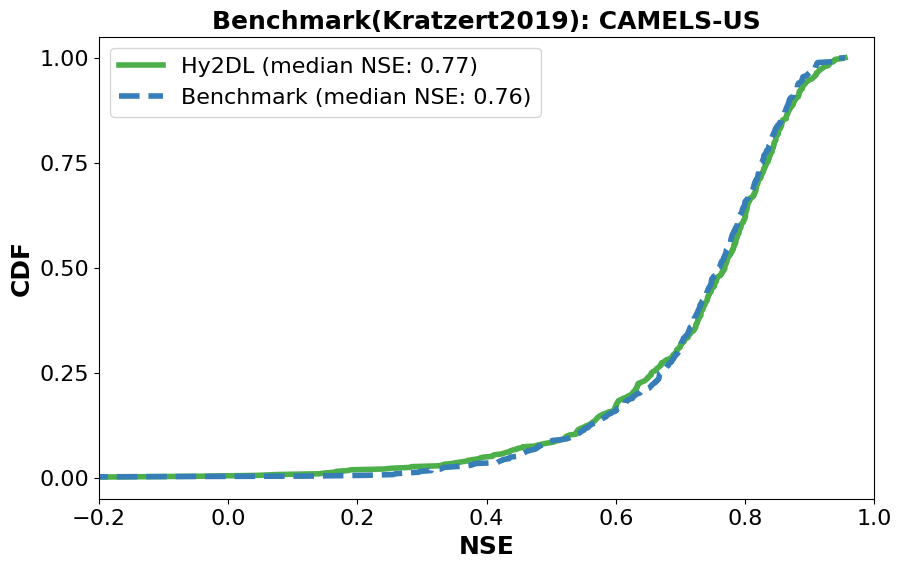

In [ ]:
NSE_comparison = pd.concat([CAMELS_US_metrics, df_NSE_Kratzert], axis=1)
NSE_comparison = NSE_comparison.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison["cdf"] = np.arange(len(NSE_comparison)) / (len(NSE_comparison) - 1)

# Create plot
plt.rcParams["figure.figsize"] = (10, 6)

plt.plot(
    NSE_comparison["LSTM"],
    NSE_comparison["cdf"],
    linewidth=4,
    label=f"Hy2DL (median NSE: {NSE_comparison['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
plt.plot(
    NSE_comparison["Benchmark_Kratzert"],
    NSE_comparison["cdf"],
    linewidth=4,
    linestyle="--",
    label=f"Benchmark (median NSE: {NSE_comparison['Benchmark_Kratzert'].median():.2f})",
    color=color_palette["benchmark"],
)


plt.xlim(-0.2, 1)
plt.xlabel("NSE", fontsize=18, fontweight="bold")
plt.ylabel("CDF", fontsize=18, fontweight="bold")
plt.xticks(fontsize=16)
plt.yticks([i * 0.25 for i in range(5)], fontsize=16)

plt.legend(loc="upper left", fontsize=16)
plt.title("Benchmark(Kratzert2019): CAMELS-US", fontsize=18, fontweight="bold")
# plt.savefig("Benchmark_Kratzert2019.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

#### Benchmark CAMELS_US - multiple forcings

Kratzert, F., Klotz, D., Hochreiter, S., & Nearing, G. S. (2021). A note on leveraging synergy in multiple meteorological data sets with deep learning for rainfall-runoff modeling. Hydrology and Earth System Sciences, 25(5), 2685–2703. https://doi.org/10.5194/hess-25-2685-2021

In [42]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Kratzert2021"

In [43]:
# Read the results generated by Kratzert et al. (2019)
path_reference = path_data + "/reference/Kratzert2021.zarr"
kratzert_metrics = (
    calculate_metrics(ds_results=xr.open_zarr(path_reference))
    .sel(metric="nse", feature="QObs(mm/d)")
    .round(3)
    .T.to_pandas()
    .to_frame(name="Benchmark_Kratzert")
)

In [44]:
# Calculate ensemble median and metrics for our LSTM results
path_results = glob.glob(path_data + "/results/*/")
ds = calculate_median_ensemble(path_results)
ds_metrics = calculate_metrics(ds_results=ds)
CAMELS_US_multiple_forcings_metrics = (
    ds_metrics.sel(metric="nse", feature="QObs(mm/d)").round(3).T.to_pandas().to_frame(name="LSTM")
)

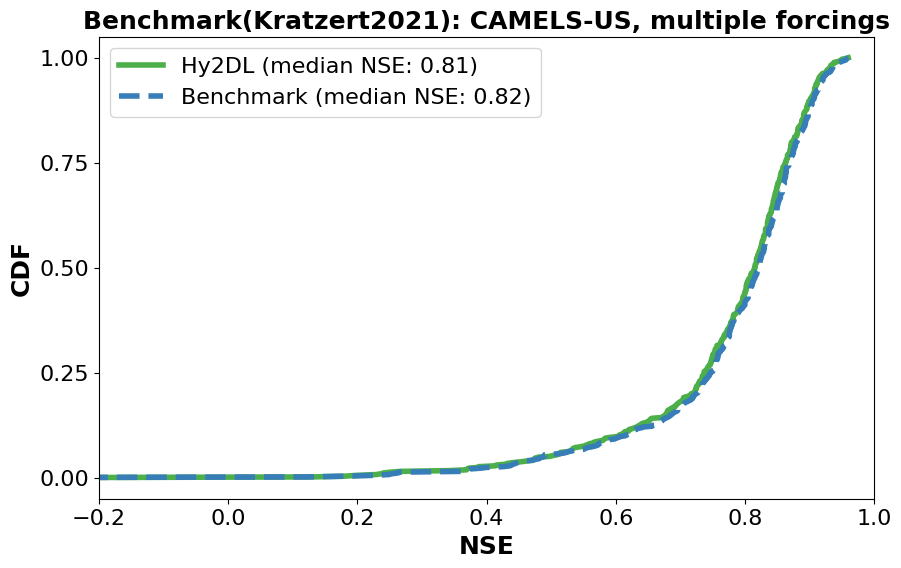

In [ ]:
NSE_comparison = pd.concat([CAMELS_US_multiple_forcings_metrics, kratzert_metrics], axis=1)
NSE_comparison = NSE_comparison.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison["cdf"] = np.arange(len(NSE_comparison)) / (len(NSE_comparison) - 1)

# Create plot
plt.rcParams["figure.figsize"] = (10, 6)

plt.plot(
    NSE_comparison["LSTM"],
    NSE_comparison["cdf"],
    linewidth=4,
    label=f"Hy2DL (median NSE: {NSE_comparison['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
plt.plot(
    NSE_comparison["Benchmark_Kratzert"],
    NSE_comparison["cdf"],
    linewidth=4,
    linestyle="--",
    label=f"Benchmark (median NSE: {NSE_comparison['Benchmark_Kratzert'].median():.2f})",
    color=color_palette["benchmark"],
)


plt.xlim(-0.2, 1)
plt.xlabel("NSE", fontsize=18, fontweight="bold")
plt.ylabel("CDF", fontsize=18, fontweight="bold")
plt.xticks(fontsize=16)
plt.yticks([i * 0.25 for i in range(5)], fontsize=16)

plt.legend(loc="upper left", fontsize=16)
plt.title("Benchmark(Kratzert2021): CAMELS-US, multiple forcings", fontsize=18, fontweight="bold")
# plt.savefig("Benchmark_Kratzert2021.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

#### Benchmark LSTM-MDN 

Klotz, D., Kratzert, F., Gauch, M., Keefe Sampson, A., Brandstetter, J., Klambauer, G., Hochreiter, S., & Nearing, G. (2022). Uncertainty estimation with deep learning for rainfall-runoff modeling. Hydrology and Earth System Sciences, 26(6), 1673–1693. https://doi.org/10.5194/hess-26-1673-2022

In [53]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Klotz2022"

In [54]:
# Calculate ensemble median and metrics for our LSTM results
cmal_metrics = (
    xr.open_zarr(path_data + "/results/MDN_CMAL_seed_42/testing_metrics.zarr")["__xarray_dataarray_variable__"]
    .sel(metric="nse", feature="QObs(mm/d)")
    .round(3)
    .T.to_pandas()
    .to_frame(name="CMAL")
)
gmm_metrics = (
    xr.open_zarr(path_data + "/results/MDN_GMM_seed_42/testing_metrics.zarr")["__xarray_dataarray_variable__"]
    .sel(metric="nse", feature="QObs(mm/d)")
    .round(3)
    .T.to_pandas()
    .to_frame(name="GMM")
)

In [ ]:
# Calculate PIT values
bins = torch.tensor([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# CMAL
distribution = get_distribution("laplacian")
results_cmal = xr.open_zarr(path_data + "/results/MDN_CMAL_seed_42/testing_results.zarr")
params = {}
for var in list(distribution.parameters):
    params[var] = torch.tensor(results_cmal[var].values)
weights = torch.tensor(results_cmal["mdn_weight"].values)
y_obs = torch.tensor(results_cmal["y_obs"].values)
with torch.no_grad():
    pit_values_cmal = distribution.pit(params=params, weights=weights, x=y_obs, bins=bins)[0].numpy()

# GMM
distribution = get_distribution("gaussian")
results_gmm = xr.open_zarr(path_data + "/results/MDN_GMM_seed_42/testing_results.zarr")
params = {}
for var in list(distribution.parameters):
    params[var] = torch.tensor(results_gmm[var].values)
    weights = torch.tensor(results_gmm["mdn_weight"].values)
    y_obs = torch.tensor(results_gmm["y_obs"].values)
with torch.no_grad():
    pit_values_gmm = distribution.pit(params=params, weights=weights, x=y_obs, bins=bins)[0].numpy()

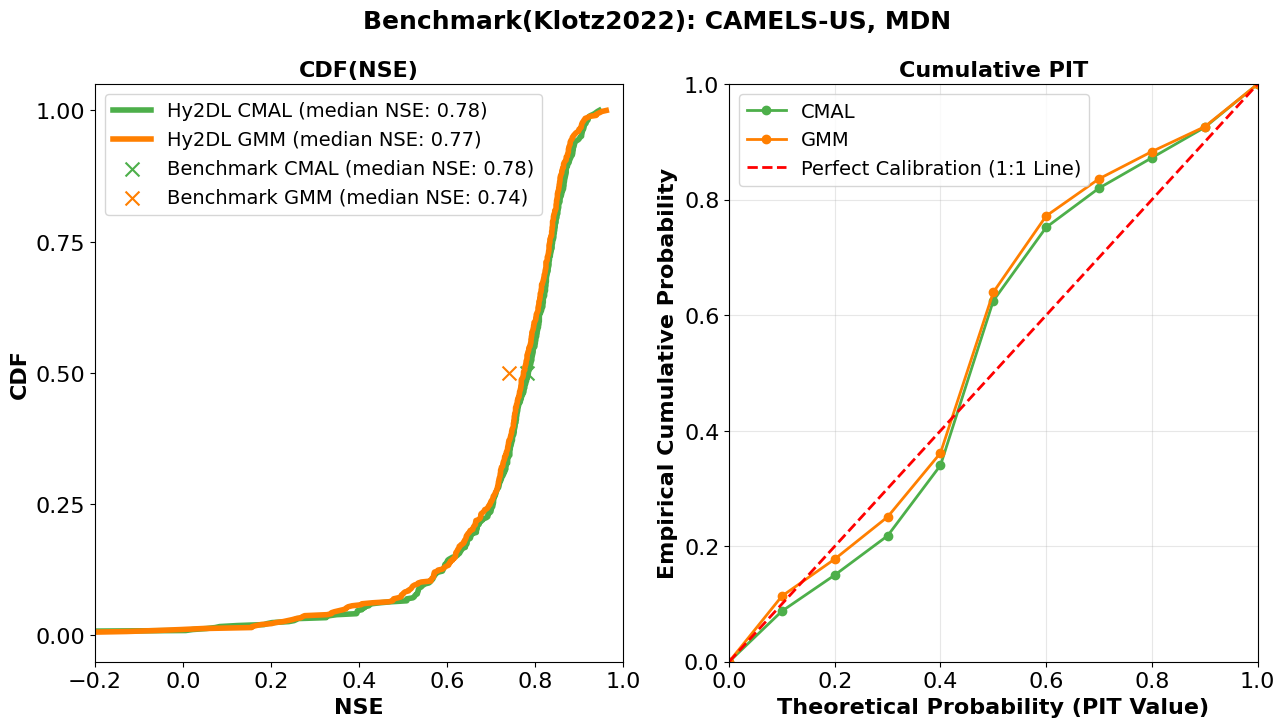

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7.5))

# CDF-NSE
NSE_comparison = pd.concat([cmal_metrics, gmm_metrics], axis=1)
NSE_comparison = NSE_comparison.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison["cdf"] = np.arange(len(NSE_comparison)) / (len(NSE_comparison) - 1)

axs[0].plot(
    NSE_comparison["CMAL"],
    NSE_comparison["cdf"],
    linewidth=4,
    label=f"Hy2DL CMAL (median NSE: {NSE_comparison['CMAL'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[0].plot(
    NSE_comparison["GMM"],
    NSE_comparison["cdf"],
    linewidth=4,
    label=f"Hy2DL GMM (median NSE: {NSE_comparison['GMM'].median():.2f})",
    color=color_palette["MTS"],
)

# Taken from Table 4 pf the reference (https://doi.org/10.5194/hess-26-1673-2022)
axs[0].scatter(0.78, 0.5, s=100, marker="x", label="Benchmark CMAL (median NSE: 0.78)", color=color_palette["LSTM"])
axs[0].scatter(0.74, 0.5, s=100, marker="x", label="Benchmark GMM (median NSE: 0.74)", color=color_palette["MTS"])

axs[0].set_xlim(-0.2, 1)
axs[0].set_xlabel("NSE", fontsize=16, fontweight="bold")
axs[0].set_ylabel("CDF", fontsize=16, fontweight="bold")
axs[0].tick_params(axis="both", labelsize=16)
axs[0].set_yticks([i * 0.25 for i in range(5)])

axs[0].legend(loc="upper left", fontsize=14)
axs[0].set_title("CDF(NSE)", fontsize=16, fontweight="bold")


# model's empirical cumulative PIT
axs[1].plot(bins, pit_values_cmal, marker="o", color=color_palette["LSTM"], linewidth=2, label="CMAL")
axs[1].plot(bins, pit_values_gmm, marker="o", color=color_palette["MTS"], linewidth=2, label="GMM")
axs[1].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfect Calibration (1:1 Line)")

# Formatting
axs[1].set_xlim(0, 1)
axs[1].set_ylim(0, 1)
axs[1].set_xlabel("Theoretical Probability (PIT Value)", fontsize=16, fontweight="bold")
axs[1].set_ylabel("Empirical Cumulative Probability", fontsize=16, fontweight="bold")
axs[1].tick_params(axis="both", labelsize=16)
axs[1].grid(alpha=0.3)
axs[1].legend(loc="upper left", fontsize=14)
axs[1].set_title("Cumulative PIT", fontsize=16, fontweight="bold")

fig.suptitle("Benchmark(Klotz2022): CAMELS-US, MDN", fontsize=18, fontweight="bold")
# plt.savefig("Benchmark_Klotz2022.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

####  Benchmark hourly CAMELS_US.

Gauch, M., Kratzert, F., Klotz, D., Nearing, G., Lin, J., & Hochreiter, S. (2021). Rainfall–runoff prediction at multiple timescales with a single Long Short-Term Memory network. Hydrology and Earth System Sciences, 25(4), 2045–2062. https://doi.org/10.5194/hess-25-2045-2021

In [114]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Gauch2021"

In [133]:
NSE_MTS = xr.open_zarr(path_data + "/reference/results-zarrs/ensemble_mtslstm/data.zarr", group="1H")
NSE_MTS = NSE_MTS["NSE_1H"].to_pandas().to_frame(name="Benchmark_MTS")
NSE_MTS.index.names = ["gauge_id"]

NSE_sMTS = xr.open_zarr(path_data + "/reference/results-zarrs/ensemble_smtslstm/data.zarr", group="1H")
NSE_sMTS = NSE_sMTS["NSE_1H"].to_pandas().to_frame(name="Benchmark_sMTS")
NSE_sMTS.index.names = ["gauge_id"]

NSE_Naive = xr.open_zarr(path_data + "/reference/results-zarrs/ensemble_hourlylstm/data.zarr", group="1H")
NSE_Naive = NSE_Naive["NSE_1H"].to_pandas().to_frame(name="Benchmark_Naive")
NSE_Naive.index.names = ["gauge_id"]

NSE_MTS_ForcingsPerFreq = xr.open_zarr(
    path_data + "/reference/results-zarrs/ensemble_mtslstm_multiforcing_dailyhourly_validation/data.zarr", group="1H"
)
NSE_MTS_ForcingsPerFreq = NSE_MTS_ForcingsPerFreq["NSE_1H"].to_pandas().to_frame(name="Benchmark_MTS_multipleforcings")
NSE_MTS_ForcingsPerFreq.index.names = ["gauge_id"]


In [134]:
# Calculate ensemble median and metrics for our LSTM results

# First experiment: Same number of inputs for daily and hourly data.
path_results = glob.glob(path_data + "/results/hourly/*/")
ds = calculate_median_ensemble(path_results)
ds_metrics = calculate_metrics(ds_results=ds)
CAMELS_US_hourly_metrics = (
    ds_metrics.sel(metric="nse", feature="QObs(mm/h)").round(3).T.to_pandas().to_frame(name="LSTM")
)

# Second experiment: Different number of inputs for daily and hourly data.
path_results = glob.glob(path_data + "/results/hourly_ForcingsPerFreq/*/")
ds = calculate_median_ensemble(path_results)
ds_metrics = calculate_metrics(ds_results=ds)
CAMELS_US_hourly_ForcingsPerFreq_metrics = (
    ds_metrics.sel(metric="nse", feature="QObs(mm/h)").round(3).T.to_pandas().to_frame(name="LSTM")
)

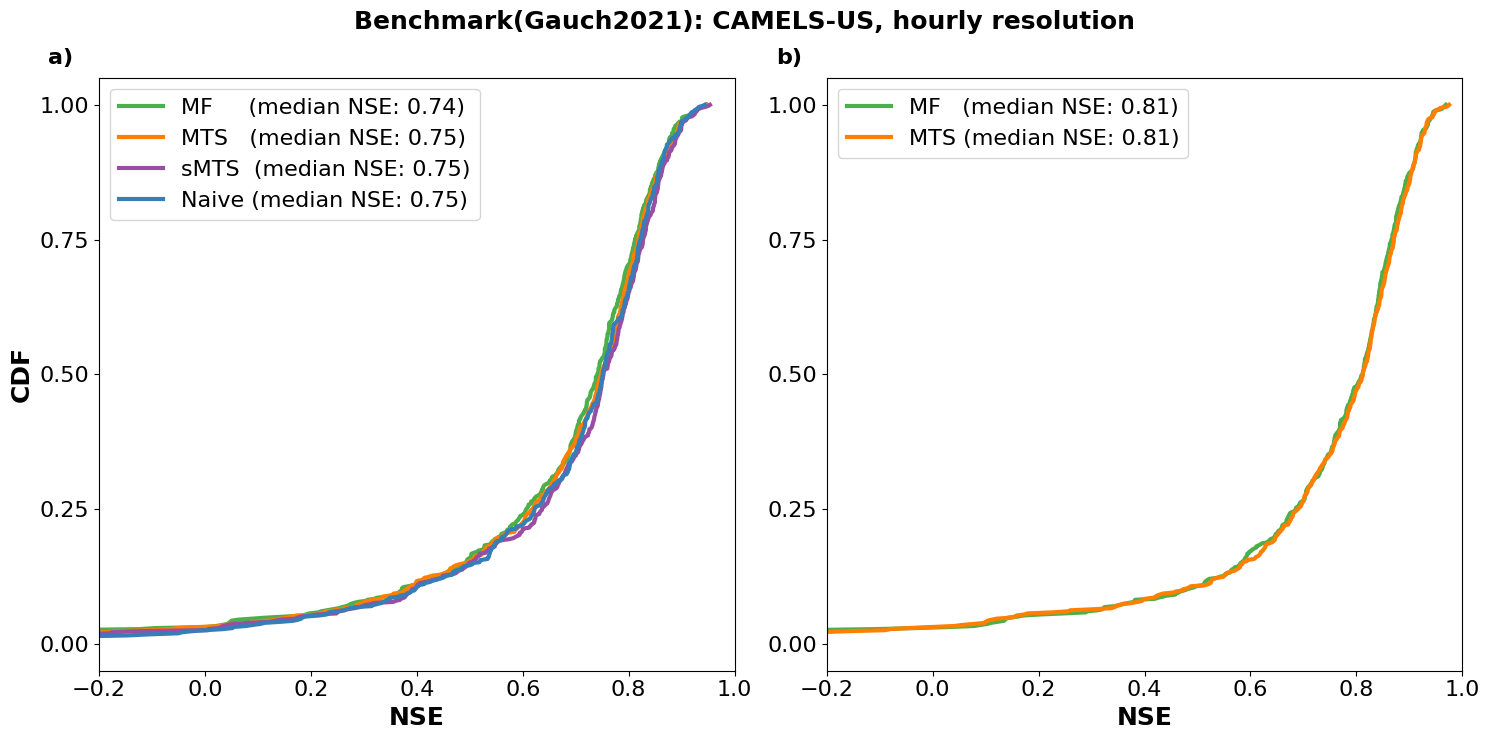

In [ ]:
# Combine results
NSE_comparison_exp1 = pd.concat([CAMELS_US_hourly_metrics, NSE_MTS, NSE_sMTS, NSE_Naive], axis=1)
NSE_comparison_exp1 = NSE_comparison_exp1.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison_exp1["cdf"] = np.arange(len(NSE_comparison_exp1)) / (len(NSE_comparison_exp1) - 1)

NSE_comparison_exp2 = pd.concat([CAMELS_US_hourly_ForcingsPerFreq_metrics, NSE_MTS_ForcingsPerFreq], axis=1)
NSE_comparison_exp2 = NSE_comparison_exp2.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison_exp2["cdf"] = np.arange(len(NSE_comparison_exp2)) / (len(NSE_comparison_exp2) - 1)

# Create a 2x1 subplot
fig, axs = plt.subplots(1, 2, figsize=(15, 7.5))

# First subplot
axs[0].plot(
    NSE_comparison_exp1["LSTM"],
    NSE_comparison_exp1["cdf"],
    linewidth=3,
    label=f"MF     (median NSE: {NSE_comparison_exp1['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[0].plot(
    NSE_comparison_exp1["Benchmark_MTS"],
    NSE_comparison_exp1["cdf"],
    linewidth=3,
    label=f"MTS   (median NSE: {NSE_comparison_exp1['Benchmark_MTS'].median():.2f})",
    color=color_palette["MTS"],
)
axs[0].plot(
    NSE_comparison_exp1["Benchmark_sMTS"],
    NSE_comparison_exp1["cdf"],
    linewidth=3,
    label=f"sMTS  (median NSE: {NSE_comparison_exp1['Benchmark_sMTS'].median():.2f})",
    color=color_palette["sMTS"],
)
axs[0].plot(
    NSE_comparison_exp1["Benchmark_Naive"],
    NSE_comparison_exp1["cdf"],
    linewidth=3,
    label=f"Naive (median NSE: {NSE_comparison_exp1['Benchmark_Naive'].median():.2f})",
    color=color_palette["benchmark"],
)

# Set limits and labels for the first subplot
axs[0].set_xlim(-0.2, 1)
axs[0].set_xlabel("NSE", fontsize=18, fontweight="bold")
axs[0].set_ylabel("CDF", fontsize=18, fontweight="bold")
axs[0].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[0].set_yticks(np.arange(0, 1.25, 0.25))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[0].legend(loc="upper left", fontsize=16)
axs[0].text(-0.08, 1.05, "a)", transform=axs[0].transAxes, fontsize=16, fontweight="bold", verticalalignment="top")

# Second subplot
axs[1].plot(
    NSE_comparison_exp2["LSTM"],
    NSE_comparison_exp2["cdf"],
    linewidth=3,
    label=f"MF   (median NSE: {NSE_comparison_exp2['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[1].plot(
    NSE_comparison_exp2["Benchmark_MTS_multipleforcings"],
    NSE_comparison_exp2["cdf"],
    linewidth=3,
    label=f"MTS (median NSE: {NSE_comparison_exp2['Benchmark_MTS_multipleforcings'].median():.2f})",
    color=color_palette["MTS"],
)

# Set limits and labels for the second subplot
axs[1].set_xlim(-0.2, 1)
axs[1].set_xlabel("NSE", fontsize=18, fontweight="bold")
axs[1].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[1].set_yticks(np.arange(0, 1.25, 0.25))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[1].legend(loc="upper left", fontsize=16)
axs[1].text(-0.08, 1.05, "b)", transform=axs[1].transAxes, fontsize=16, fontweight="bold", verticalalignment="top")

fig.suptitle("Benchmark(Gauch2021): CAMELS-US, hourly resolution", fontsize=18, fontweight="bold")
plt.tight_layout()
# plt.savefig("Benchmark_Gauch2021.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

#### Hybrids
Here we test our implementation of the hybrid models by comparing it to stand-alone single-seed LSTMs. These implementation are not intended to act as state-of-the-art for hybrid models, and
their main objective is to validate our hybrid model subroutines.

- For GB we test LSTM+SHM, using all parameters of the SHM being dynamic. 
    - References: https://doi.org/10.5194/hess-30-629-2026, https://doi.org/10.5194/hess-28-2705-2024
- For US we tested LSTM+16HBVs, with 2 parameters of each of the 16 HBVs being dynamic. 
    - Reference:  https://doi.org/10.1029/2022WR032404,  https://doi.org/10.5194/hess-29-1277-2025

In [82]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Hybrids"

In [ ]:
# Calculate ensemble median and metrics for our LSTM results
hybrid_us_metrics = (
    xr.open_zarr(path_data + "/results/Hybrid_CAMELS_US_seed_110/testing_metrics.zarr")["__xarray_dataarray_variable__"]
    .sel(metric="nse", feature="QObs(mm/d)")
    .round(3)
    .T.to_pandas()
    .to_frame(name="Hybrid_US")
)

lstm_us_metrics = (
    xr.open_zarr("G:/My Drive/KIT/Hy2DL/benchmarks/Kratzert2019/results/LSTM_CAMELS_US_seed_111/testing_metrics.zarr")[
        "__xarray_dataarray_variable__"
    ]
    .sel(metric="nse", feature="QObs(mm/d)")
    .round(3)
    .T.to_pandas()
    .to_frame(name="LSTM_US")
)

hybrid_gb_metrics = (
    xr.open_zarr(path_data + "/results/Hybrid_CAMELS_GB_seed_110/testing_metrics.zarr")["__xarray_dataarray_variable__"]
    .sel(metric="nse", feature="discharge_spec")
    .round(3)
    .T.to_pandas()
    .to_frame(name="Hybrid_GB")
)

lstm_gb_metrics = (
    xr.open_zarr("G:/My Drive/KIT/Hy2DL/benchmarks/Lees2021/results/LSTM_CAMELS_GB_seed_1/testing_metrics.zarr")[
        "__xarray_dataarray_variable__"
    ]
    .sel(metric="nse", feature="discharge_spec")
    .round(3)
    .T.to_pandas()
    .to_frame(name="LSTM_GB")
)

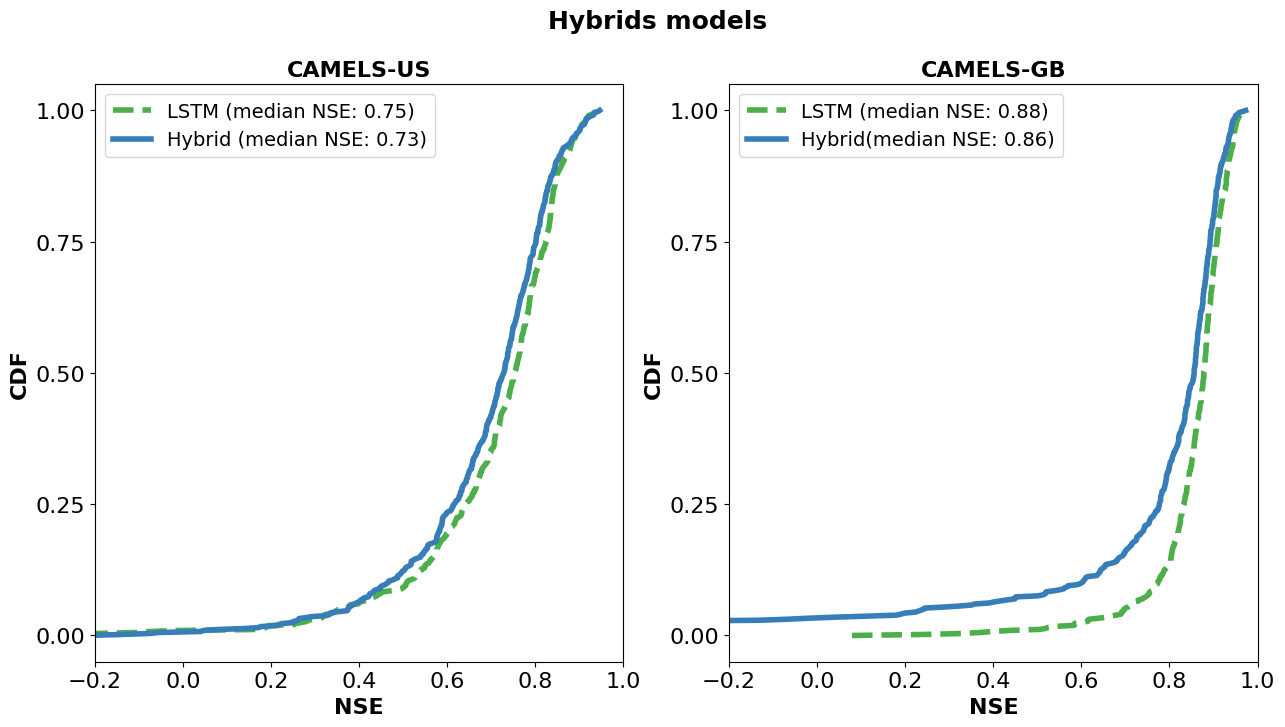

In [ ]:
NSE_comparison_us = pd.concat([hybrid_us_metrics, lstm_us_metrics], axis=1)
NSE_comparison_us = NSE_comparison_us.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison_us["cdf"] = np.arange(len(NSE_comparison_us)) / (len(NSE_comparison_us) - 1)

NSE_comparison_gb = pd.concat([hybrid_gb_metrics, lstm_gb_metrics], axis=1)
NSE_comparison_gb = NSE_comparison_gb.apply(lambda x: x.sort_values().values).reset_index(drop=True)
NSE_comparison_gb["cdf"] = np.arange(len(NSE_comparison_gb)) / (len(NSE_comparison_gb) - 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 7.5))

# US ----
axs[0].plot(
    NSE_comparison_us["LSTM_US"],
    NSE_comparison_us["cdf"],
    linewidth=4,
    linestyle="--",
    label=f"LSTM (median NSE: {NSE_comparison_us['LSTM_US'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[0].plot(
    NSE_comparison_us["Hybrid_US"],
    NSE_comparison_us["cdf"],
    linewidth=4,
    label=f"Hybrid (median NSE: {NSE_comparison_us['Hybrid_US'].median():.2f})",
    color=color_palette["benchmark"],
)

axs[0].set_xlim(-0.2, 1)
axs[0].set_xlabel("NSE", fontsize=16, fontweight="bold")
axs[0].set_ylabel("CDF", fontsize=16, fontweight="bold")
axs[0].tick_params(axis="both", labelsize=16)
axs[0].set_yticks([i * 0.25 for i in range(5)])

axs[0].legend(loc="upper left", fontsize=14)
axs[0].set_title("CAMELS-US", fontsize=16, fontweight="bold")


# GB ----
axs[1].plot(
    NSE_comparison_gb["LSTM_GB"],
    NSE_comparison_gb["cdf"],
    linewidth=4,
    linestyle="--",
    label=f"LSTM (median NSE: {NSE_comparison_gb['LSTM_GB'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[1].plot(
    NSE_comparison_gb["Hybrid_GB"],
    NSE_comparison_gb["cdf"],
    linewidth=4,
    label=f"Hybrid(median NSE: {NSE_comparison_gb['Hybrid_GB'].median():.2f})",
    color=color_palette["benchmark"],
)

axs[1].set_xlim(-0.2, 1)
axs[1].set_xlabel("NSE", fontsize=16, fontweight="bold")
axs[1].set_ylabel("CDF", fontsize=16, fontweight="bold")
axs[1].tick_params(axis="both", labelsize=16)
axs[1].set_yticks([i * 0.25 for i in range(5)])

axs[1].legend(loc="upper left", fontsize=14)
axs[1].set_title("CAMELS-GB", fontsize=16, fontweight="bold")

fig.suptitle("Hybrids models", fontsize=18, fontweight="bold")
# plt.savefig("Hybrids.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

#### Benchmark missing inputs.

Gauch, M., Kratzert, F., Klotz, D., Nearing, G., Cohen, D., & Gilon, O. (2025). How to deal w___ missing input data. Hydrology and Earth System Sciences, 29(21), 6221–6235. https://doi.org/10.5194/hess-29-6221-2025

In [ ]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Gauch2025"
seeds = ["0", "1", "2"]
nan_prob = ["00","01", "02", "03", "04", "05", "06"]

In [39]:
def load_reference_metrics_nansweep(base_folder, nan_prob, seeds):
    data_dict = {}
    for nan in nan_prob:
        dfs = []
        for seed in seeds:
            subfolder = base_folder +f"/seed{seed}_nanprob{nan}"
            df = pd.read_csv(subfolder + "/test_metrics.csv")
            dfs.append(df["NSE"].rename(f"seed{seed}"))

        combined_df = pd.concat(dfs, axis=1)
        data_dict[f"{nan[0]}.{nan[1]}"] = combined_df
  
    return data_dict

In [40]:
# Read the results generated by Gauch et al. (2025)
results_gauch_im = load_reference_metrics_nansweep(path_data + "/reference/nansweep_step_lr25_v2/im",
                                nan_prob=nan_prob, seeds=seeds)
results_gauch_mme = load_reference_metrics_nansweep(path_data + "/reference/nansweep_step_lr25_v2/mme",
                                nan_prob=nan_prob, seeds=seeds)

In [ ]:
# Results generated with Hy2DL
path_results_mme = glob.glob(path_data + "/results/nan_sweep/mme/*/")
results_mme = {}
for path_id in path_results_mme:
    results_mme[path_id.split("nanprob_")[-1][:3]] = (
        xr.open_zarr(path_id + "testing_metrics.zarr")["__xarray_dataarray_variable__"]
        .sel(metric="nse", feature="QObs(mm/d)")
        .round(3)
        .T.to_pandas()
        .to_frame(name="NSE")
    )

path_results_im = glob.glob(path_data + "/results/nan_sweep/im/*/")
results_im = {}
for path_id in path_results_im:
    results_im[path_id.split("nanprob_")[-1][:3]] = (
        xr.open_zarr(path_id + "testing_metrics.zarr")["__xarray_dataarray_variable__"]
        .sel(metric="nse", feature="QObs(mm/d)")
        .round(3)
        .T.to_pandas()
        .to_frame(name="NSE")
    )

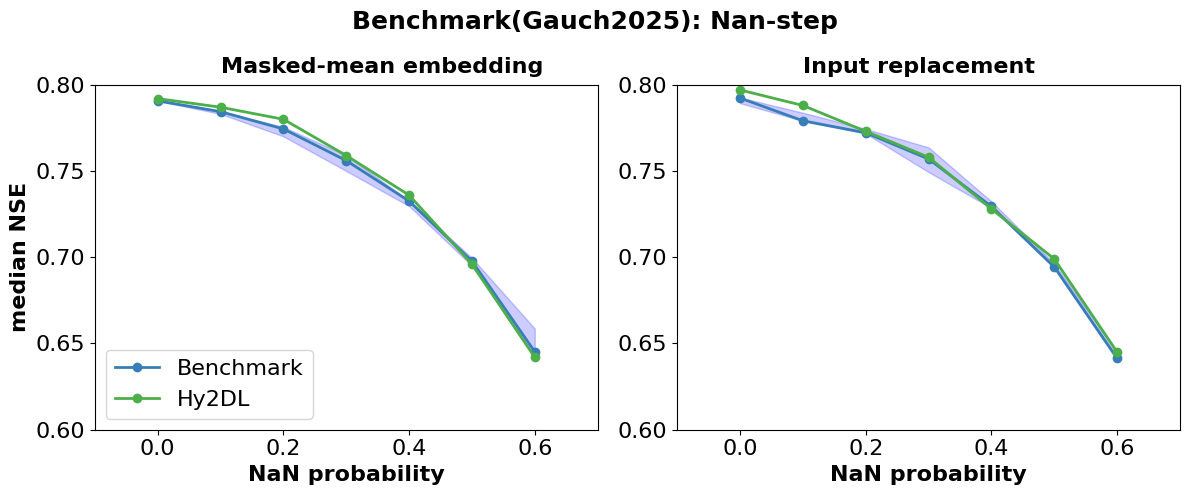

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot
xs = sorted([float(k) for k in results_gauch_mme.keys()])
xs_str = [str(i) for i in xs]

benchmark_median, benchmark_max, benchmark_min, y_sim = [], [], [], []
# 3. Use a single loop to populate all lists simultaneously
for x in xs_str:
    gauch_med = results_gauch_mme[x].median()
    benchmark_median.append(gauch_med.median())
    benchmark_max.append(gauch_med.max())
    benchmark_min.append(gauch_med.min())
    y_sim.append(results_mme[x]["NSE"].median())

axs[0].plot(
    xs, benchmark_median, linestyle="-", marker="o", linewidth=2, color=color_palette["benchmark"], label="Benchmark"
)
axs[0].fill_between(xs, benchmark_min, benchmark_max, color="blue", alpha=0.2)
axs[0].plot(xs, y_sim, linestyle="-", marker="o", linewidth=2, color=color_palette["LSTM"], label="Hy2DL")


# Set limits and labels for the first subplot
axs[0].set_xlim(-0.1, 0.7)
axs[0].set_ylim(0.6, 0.8)
axs[0].set_xlabel("NaN probability", fontsize=16, fontweight="bold")
axs[0].set_ylabel("median NSE", fontsize=16, fontweight="bold")
axs[0].set_yticks(np.arange(0.6, 0.85, 0.05))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[0].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[0].legend(loc="lower left", fontsize=16)
axs[0].text(
    0.25,
    1.08,
    "Masked-mean embedding",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    verticalalignment="top",
)

# Second subplot
benchmark_median, benchmark_max, benchmark_min, y_sim = [], [], [], []
for x in xs_str:
    gauch_med = results_gauch_im[x].median()
    benchmark_median.append(gauch_med.median())
    benchmark_max.append(gauch_med.max())
    benchmark_min.append(gauch_med.min())
    y_sim.append(results_im[x]["NSE"].median())

axs[1].plot(
    xs, benchmark_median, linestyle="-", marker="o", linewidth=2, color=color_palette["benchmark"], label="Benchmark"
)
axs[1].fill_between(xs, benchmark_min, benchmark_max, color="blue", alpha=0.2)
axs[1].plot(xs, y_sim, linestyle="-", marker="o", linewidth=2, color=color_palette["LSTM"], label="Hy2DL")


# Set limits and labels for the second subplot
# Set limits and labels for the first subplot
axs[1].set_xlim(-0.1, 0.7)
axs[1].set_ylim(0.6, 0.8)
axs[1].set_xlabel("NaN probability", fontsize=16, fontweight="bold")
axs[1].set_yticks(np.arange(0.6, 0.85, 0.05))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[1].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[1].text(
    0.25, 1.08, "Input replacement", transform=axs[1].transAxes, fontsize=16, fontweight="bold", verticalalignment="top"
)


fig.suptitle("Benchmark(Gauch2025): Nan-step", fontsize=18, fontweight="bold")
plt.tight_layout()
# plt.savefig("Benchmark_Gauch2025_NanStep.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()


In [ ]:
path_data = "G:/My Drive/KIT/Hy2DL/benchmarks/Gauch2025"
masked_methods = ["mme", "im"]
experiments = ["daymet", "maurer", "nldas", "daymet_maurer", "daymet_nldas", "maurer_nldas"]

In [41]:
def load_reference_metrics_dropseq(path_data, masked_method, experiment, seeds):
    dfs = []
    for seed in seeds:
        file_path = (
            path_data + "/reference/drop-sequences" + f"/{masked_method}_seed{seed}" + f"/test_keep{experiment}_metrics.csv"
        )
        
        df = pd.read_csv(file_path, index_col="basin", dtype={"basin": str})
        df = df[["NSE"]].rename(columns={"NSE": f"NSE_{seed}"})
        dfs.append(df)
        
    # concatenate along columns
    df = pd.concat(dfs, axis=1)
    df["NSE"] = df.mean(axis=1)
    df = df.apply(lambda x: x.sort_values().values).reset_index(drop=True)
    df["cdf"] = np.arange(len(df)) / (len(df) - 1)
    return df

In [44]:
def load_hy2dl_metrics_dropseq(path_data, masked_method, experiment, seeds):
    dfs = []
    for seed in seeds:
        file_path = (
            path_data
            + f"/results/drop_seq/{masked_method}/camels_us_missingsequence_{masked_method}_seed_{seed}/testing_metrics_{experiment}.zarr"
        )

        df = (
            xr.open_zarr(file_path)["__xarray_dataarray_variable__"]
            .sel(metric="nse", feature="QObs(mm/d)")
            .round(3)
            .T.to_pandas()
            .to_frame(name="NSE")
        )
        
        df = df[["NSE"]].rename(columns={"NSE": f"NSE_{seed}"})
        dfs.append(df)
        
    # concatenate along columns
    df = pd.concat(dfs, axis=1)
    df["NSE"] = df.mean(axis=1)
    df = df.apply(lambda x: x.sort_values().values).reset_index(drop=True)
    df["cdf"] = np.arange(len(df)) / (len(df) - 1)
    return df

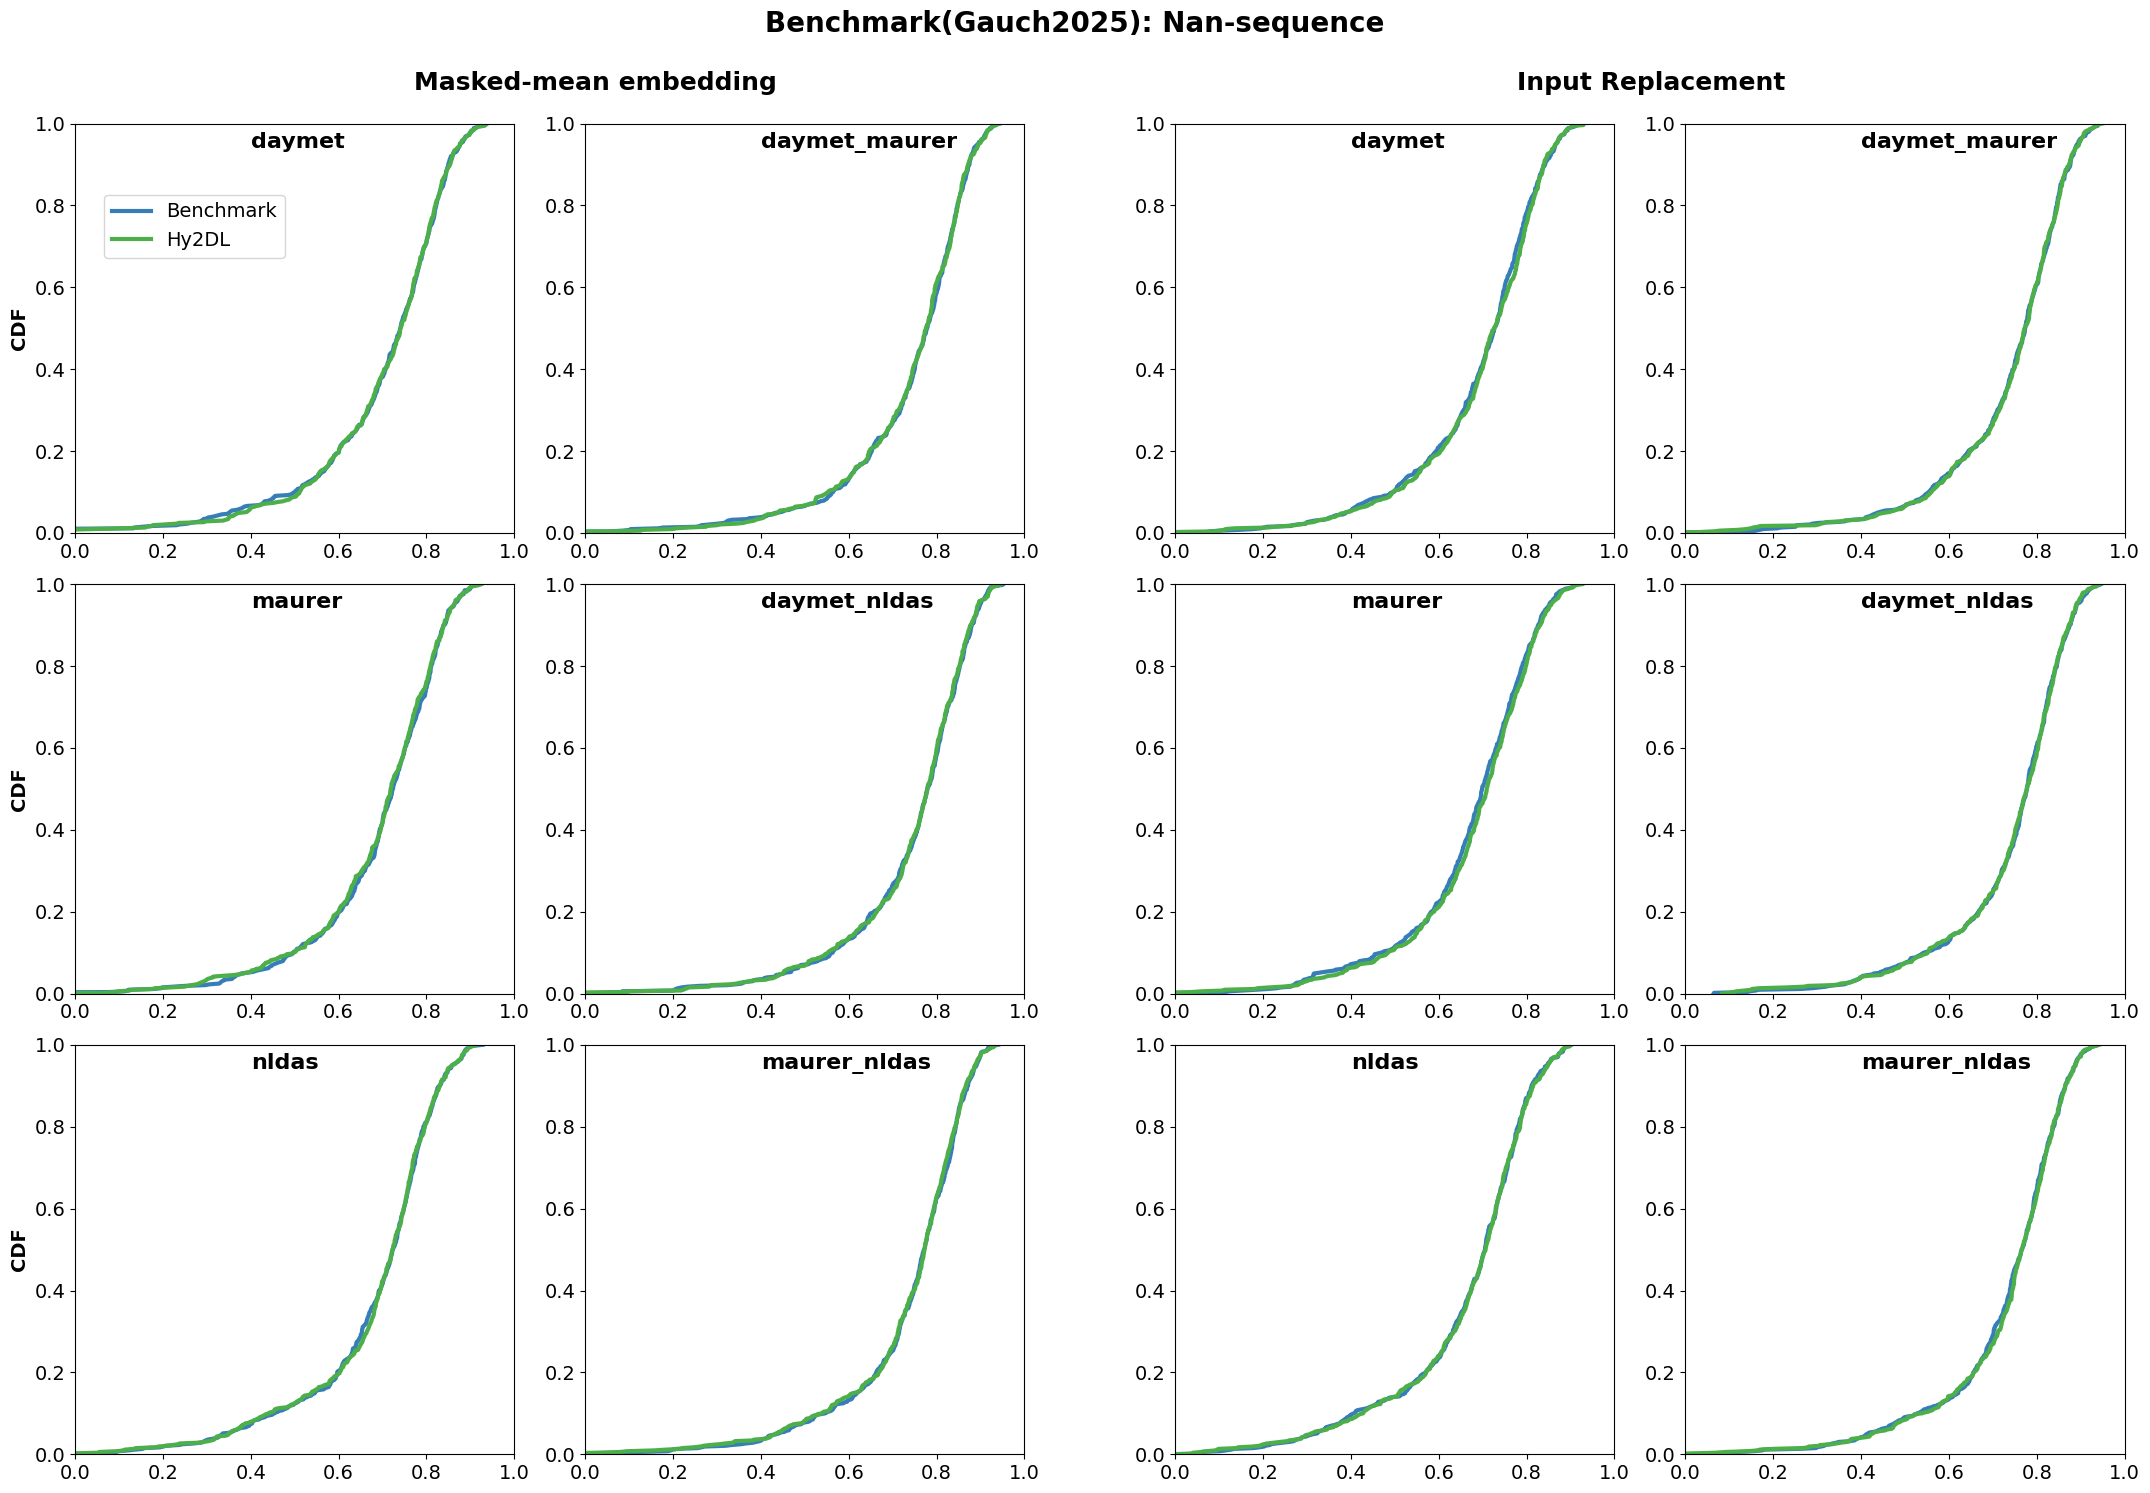

In [49]:
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 0.02, 1, 1])
axs = np.empty((3, 4), dtype=object)

# Populate the axs array, manually handling shared axes
for r in range(3):
    for c in range(4):
        grid_col = c if c < 2 else c + 1
        share_ax = {"sharex": axs[0, 0], "sharey": axs[0, 0]} if (r, c) != (0, 0) else {}
        axs[r, c] = fig.add_subplot(gs[r, grid_col], **share_ax)
        
# Populate the plots
for i, method in enumerate(masked_methods):
    for j, experiment in enumerate(experiments):
        
        r = j % 3              
        c = (j // 3) + (i * 2)
        ax = axs[r, c]
        
        # Load and plot benchmark
        benchmark = load_reference_metrics_dropseq(path_data, method, experiment, seeds)
        ax.plot(benchmark["NSE"], benchmark["cdf"], linewidth=3, color=color_palette["benchmark"], label="Benchmark")
        
        # Load and plot Hy2DL
        hy2dl = load_hy2dl_metrics_dropseq(path_data, method, experiment, seeds)
        ax.plot(hy2dl["NSE"], hy2dl["cdf"], linewidth=3, color=color_palette["LSTM"], label="Hy2DL")
        
        ax.text(0.4, 0.98, experiment, transform=ax.transAxes, fontsize=16, fontweight="bold", verticalalignment="top")
        
        # Formatting: Only add the Y-label to the absolute leftmost column (c=0)
        if c == 0:
            ax.set_ylabel("CDF", fontsize=14, fontweight="bold")
            
        # Formatting: Only add the legend to the very first plot
        if r == 0 and c == 0:
            ax.legend(loc="upper right", bbox_to_anchor=(0.50, 0.85), fontsize=14)
            
for ax in axs.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.2, 0.2))
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.tick_params(axis="both", labelsize=14)

# --- Add column subtitles ---
fig.text(0.30, 0.93, "Masked-mean embedding", ha="center", fontsize=18, fontweight="bold")
fig.text(0.74, 0.93, "Input Replacement", ha="center", fontsize=18, fontweight="bold")

fig.suptitle("Benchmark(Gauch2025): Nan-sequence", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
# plt.savefig("Benchmark_Gauch2025_NanSequence.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()